In [8]:
import matplotlib.pyplot as plt
import numpy as np

from plots import create_delta_plot_rdmc, create_pushforward_plot_rdmc

In [38]:
rng = np.random.default_rng(2025)

def rdm_experiment_simple(
    v_intercept,
    v_slope,
    s_true,
    b,
    t0,
    num_obs=1000
):
    """Simulates data from a single subject in a multi-alternative response times experiment."""
    # if np.any(np.array((v_intercept, v_slope, s_true, b, t0)) <= 0):
    #     raise ValueError("Model parameters must be positive")

    num_accumulators = 2

    # Acc1 = false, Acc2 = true
    v = np.hstack([v_intercept, v_intercept + v_slope])
    s = np.hstack([1.0, s_true])

    mu = b / v
    lam = (b / s) ** 2

    # First passage time
    fpt = np.zeros((num_accumulators, num_obs))
    
    for i in range(num_accumulators):
        fpt[i, :] = rng.wald(mu[i], lam[i], size=num_obs)

    resp = fpt.argmin(axis=0)
    rt = fpt.min(axis=0) + t0

    return {"x": np.c_[rt, resp]}

def rdm_experiment_simple_conditions(**kwargs):
    v_congruent = kwargs.pop("v_slope_congruent")
    v_incongruent = kwargs.pop("v_slope_incongruent")
    s_congruent = kwargs.pop("s_true_congruent")
    s_incongruent = kwargs.pop("s_true_incongruent")

    data_congruent = rdm_experiment_simple(
        v_slope=v_congruent,
        s_true=s_congruent,
        **kwargs
    )

    data_incongruent = rdm_experiment_simple(
        v_slope=v_incongruent,
        s_true=s_incongruent,
        **kwargs
    )

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

In [63]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=1.5,
    v_slope_incongruent=1.0,
    s_true_congruent=1.0,
    s_true_incongruent=2.0,
    b=1.0,
    t0=0.3,
    num_obs=10000,
)

data = rdm_experiment_simple_conditions(**params)

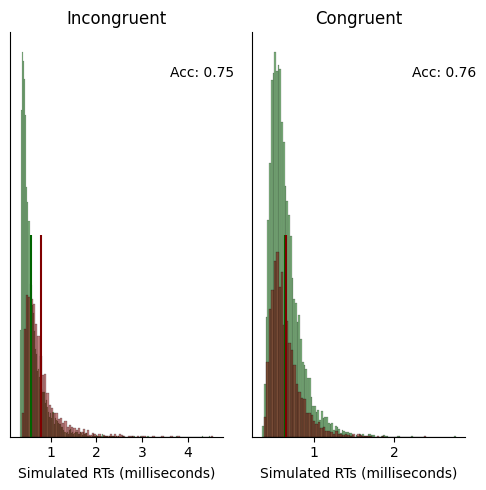

In [64]:
_ = create_pushforward_plot_rdmc(data)

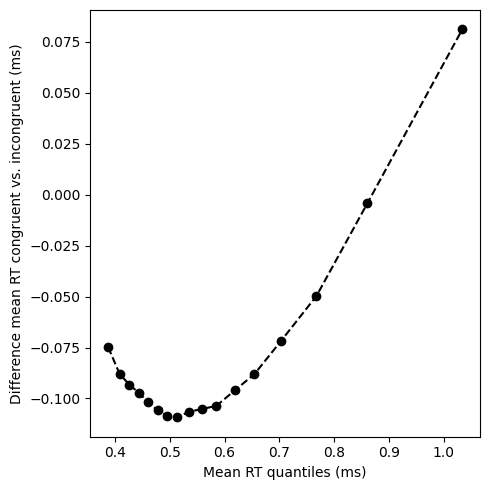

In [65]:
_ = create_delta_plot_rdmc(data)